# Projeto Integrador II — Ciência de Dados
## Análise das Unidades Básicas de Saúde (UBS) da Paraíba

Este notebook apresenta a inspeção inicial da base de dados de Unidades Básicas de Saúde (UBS), com recorte para o estado da Paraíba.

### Perguntas de pesquisa

1. Como as UBS estão distribuídas entre os municípios da Paraíba?
2. Quais municípios da Paraíba possuem a maior e a menor quantidade de UBS?
3. Como as UBS estão distribuídas geograficamente na Paraíba?

### 1. Importação da biblioteca

Importação da biblioteca Pandas, utilizada para leitura, manipulação e análise dos dados.

In [ ]:
import pandas as pd

### 2. Carregamento da base de dados

Leitura do arquivo CSV contendo os dados das Unidades Básicas de Saúde (UBS).
O separador `;` foi informado para que as colunas fossem reconhecidas corretamente.

In [ ]:
df = pd.read_csv("Unidades_Basicas_Saude-UBS.csv", sep=";")

### 3. Inspeção inicial da base

Nesta etapa, são verificadas as dimensões da base, os tipos das variáveis, a presença de valores ausentes e as estatísticas descritivas iniciais.

In [ ]:
df.shape

(47972, 8)

In [ ]:
df.dtypes

,0
CNES,int64
UF,int64
IBGE,int64
NOME,object
LOGRADOURO,object
BAIRRO,object
LATITUDE,float64
LONGITUDE,object


In [ ]:
df.isna().sum()

,0
CNES,0
UF,0
IBGE,0
NOME,1
LOGRADOURO,0
BAIRRO,0
LATITUDE,1920
LONGITUDE,1919


In [ ]:
df.describe()

,CNES,UF,IBGE,LATITUDE
count,4.797200e+04,47972.000000,47972.000000,46052.000000
mean,4.008832e+06,31.143334,312925.616589,-15.227558
std,2.464400e+06,9.459358,94830.235857,8.307053
min,1.080000e+02,11.000000,110001.000000,-33.692000
25%,2.332448e+06,25.000000,250625.000000,-22.495720
50%,2.754138e+06,31.000000,312160.000000,-15.888078
75%,6.000288e+06,35.000000,354850.000000,-7.587130
max,9.999949e+06,53.000000,530040.000000,4.669034


In [ ]:
df["UF"].value_counts()

,count
UF,
31,6171
35,5839
29,4470
26,3028
23,2503
33,2402
21,2391
41,2381
43,2350


### 4. Recorte dos dados da Paraíba

Como o projeto tem como foco o estado da Paraíba, foi realizado um filtro utilizando o código da UF 25, correspondente à Paraíba.

In [ ]:
df_pb = df[df["UF"] == 25].copy()

In [ ]:
df_pb.shape

(1789, 8)

### 5. Inspeção dos dados da Paraíba

Após o recorte, foi realizada uma nova inspeção para verificar os registros pertencentes à Paraíba, confirmar o filtro aplicado e identificar a quantidade de municípios presentes na base.

In [ ]:
df_pb.head()

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
27,2505002,25,250370,UNIDADE BASICA DE SAUDE JOSE LOPES DE LIRA,RUA NOSSA SENHORA DE APARECIDA,DIST DE ENG AVIDOS,-6.900311,"-38,5258769989"
309,2321068,25,250550,UNIDADE BASICA DE SAUDE MARLUCIA GOMES DE ARAUJO,MARIA GIL DE MEDEIROS,CENTRO,-6.810128,"-37,5744201227"
310,2362104,25,251365,POSTO DE SAUDE DE FAZENDA NOVA,DISTRITO DE FAZENDA NOVA,DISTRITO,-6.448828,"-38,4830367565"
357,2612577,25,250090,UNIDADE DE SAUDE DA FAMILIA II,RUA SENADOR RUI CARNEIRO,CENTRO,-6.834333,"-35,7638239861"
411,3027066,25,250180,UBS SESI III,AVENIDA LIBERDADE,SESI,-7.122398,"-34,9146366119"


In [ ]:
df_pb["UF"].value_counts()

,count
UF,
25,1789


In [ ]:
df_pb["IBGE"].nunique()


221

A base contém registros de UBS distribuídos em 221 municípios da Paraíba.

In [ ]:
df_pb["IBGE"].value_counts()


,count
IBGE,
250750,138
250400,103
251370,49
251620,47
251080,45
...,...
250530,1
251394,1
250937,1


### 6. Qualidade e características dos dados

Nesta etapa, são verificados os valores ausentes, os tipos das variáveis e as estatísticas descritivas do recorte da Paraíba.

In [ ]:
df_pb.isna().sum()


,0
CNES,0
UF,0
IBGE,0
NOME,0
LOGRADOURO,0
BAIRRO,0
LATITUDE,59
LONGITUDE,59


Foram identificados 59 valores ausentes na variável LATITUDE e 59 na variável LONGITUDE. As demais variáveis não apresentam valores ausentes.

In [ ]:
df_pb.dtypes

,0
CNES,int64
UF,int64
IBGE,int64
NOME,object
LOGRADOURO,object
BAIRRO,object
LATITUDE,float64
LONGITUDE,object


In [ ]:
df_pb.describe()

,CNES,UF,IBGE,LATITUDE
count,1.789000e+03,1789.0,1789.000000,1730.000000
mean,3.908570e+06,25.0,250821.216881,-7.079971
std,2.302209e+06,0.0,486.670772,0.349259
min,3.689000e+03,25.0,250010.000000,-8.390865
25%,2.363941e+06,25.0,250400.000000,-7.256135
50%,2.613107e+06,25.0,250750.000000,-7.109863
75%,5.116457e+06,25.0,251240.000000,-6.848676
max,9.998306e+06,25.0,251740.000000,-6.098676


### 7. Identificação dos municípios

Como a base de UBS apresenta apenas o código IBGE dos municípios, utilizamos a API do IBGE para obter os respectivos nomes e facilitar a interpretação dos resultados.

In [ ]:
url = "https://servicodados.ibge.gov.br/api/v1/localidades/estados/PB/municipios"

municipios = pd.read_json(url)

municipios.head()

,id,nome,microrregiao,regiao-imediata
0,2500106,Água Branca,"{'id': 25007, 'nome': 'Serra do Teixeira', 'me...","{'id': 250009, 'nome': 'Patos', 'regiao-interm..."
1,2500205,Aguiar,"{'id': 25005, 'nome': 'Piancó', 'mesorregiao':...","{'id': 250010, 'nome': 'Itaporanga', 'regiao-i..."
2,2500304,Alagoa Grande,"{'id': 25015, 'nome': 'Brejo Paraibano', 'meso...","{'id': 250005, 'nome': 'Campina Grande', 'regi..."
3,2500403,Alagoa Nova,"{'id': 25015, 'nome': 'Brejo Paraibano', 'meso...","{'id': 250005, 'nome': 'Campina Grande', 'regi..."
4,2500502,Alagoinha,"{'id': 25016, 'nome': 'Guarabira', 'mesorregia...","{'id': 250002, 'nome': 'Guarabira', 'regiao-in..."


In [ ]:
municipios = municipios[["id", "nome"]].copy()

municipios["IBGE"] = municipios["id"] // 10

municipios.head()

,id,nome,IBGE
0,2500106,Água Branca,250010
1,2500205,Aguiar,250020
2,2500304,Alagoa Grande,250030
3,2500403,Alagoa Nova,250040
4,2500502,Alagoinha,250050


In [ ]:
df_pb = df_pb.merge(
    municipios[["IBGE", "nome"]],
    on="IBGE",
    how="left"
)

df_pb = df_pb.rename(columns={"nome": "MUNICIPIO"})

df_pb.head()

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE,MUNICIPIO
0,2505002,25,250370,UNIDADE BASICA DE SAUDE JOSE LOPES DE LIRA,RUA NOSSA SENHORA DE APARECIDA,DIST DE ENG AVIDOS,-6.900311,"-38,5258769989",Cajazeiras
1,2321068,25,250550,UNIDADE BASICA DE SAUDE MARLUCIA GOMES DE ARAUJO,MARIA GIL DE MEDEIROS,CENTRO,-6.810128,"-37,5744201227",Vista Serrana
2,2362104,25,251365,POSTO DE SAUDE DE FAZENDA NOVA,DISTRITO DE FAZENDA NOVA,DISTRITO,-6.448828,"-38,4830367565",Joca Claudino
3,2612577,25,250090,UNIDADE DE SAUDE DA FAMILIA II,RUA SENADOR RUI CARNEIRO,CENTRO,-6.834333,"-35,7638239861",Arara
4,3027066,25,250180,UBS SESI III,AVENIDA LIBERDADE,SESI,-7.122398,"-34,9146366119",Bayeux


In [ ]:
df_pb["MUNICIPIO"].value_counts()

,count
MUNICIPIO,
João Pessoa,138
Campina Grande,103
Santa Rita,49
Sousa,47
Patos,45
...,...
Curral Velho,1
São Domingos do Cariri,1
Mato Grosso,1


In [ ]:
df_pb["CNES"].duplicated().sum()

np.int64(0)

Não foram identificados códigos CNES duplicados no recorte analisado. Assim, os 1.789 registros apresentam identificadores CNES distintos.

In [ ]:
df_pb[["UF", "IBGE", "MUNICIPIO"]].nunique()

,0
UF,1
IBGE,221
MUNICIPIO,221


In [ ]:
df_pb["MUNICIPIO"].sort_values().unique()

array(['Aguiar', 'Alagoa Grande', 'Alagoa Nova', 'Alagoinha', 'Alcantil',
       'Algodão de Jandaíra', 'Alhandra', 'Amparo', 'Aparecida', 'Arara',
       'Araruna', 'Araçagi', 'Areia', 'Areia de Baraúnas', 'Areial',
       'Aroeiras', 'Assunção', 'Bananeiras', 'Baraúna',
       'Barra de Santa Rosa', 'Barra de Santana', 'Barra de São Miguel',
       'Bayeux', 'Baía da Traição', 'Belém', 'Belém do Brejo do Cruz',
       'Bernardino Batista', 'Boa Ventura', 'Boa Vista', 'Bom Jesus',
       'Bom Sucesso', 'Bonito de Santa Fé', 'Boqueirão', 'Borborema',
       'Brejo do Cruz', 'Brejo dos Santos', 'Caaporã', 'Cabaceiras',
       'Cabedelo', 'Cachoeira dos Índios', 'Cacimba de Areia',
       'Cacimba de Dentro', 'Cacimbas', 'Caiçara', 'Cajazeiras',
       'Cajazeirinhas', 'Caldas Brandão', 'Camalaú', 'Campina Grande',
       'Capim', 'Caraúbas', 'Carrapateira', 'Casserengue', 'Catingueira',
       'Catolé do Rocha', 'Caturité', 'Conceição', 'Condado', 'Conde',
       'Congo', 'Coremas', 'Co

Não foram identificadas categorias inconsistentes nos nomes dos municípios analisados. Os 221 municípios aparecem com grafia única no recorte da Paraíba.

In [ ]:
df_pb[["LATITUDE", "LONGITUDE"]].describe()

,LATITUDE,LONGITUDE
count,1730.000000,1730.000000
mean,-7.079971,-36.367318
std,0.349259,1.231492
min,-8.390865,-38.720458
25%,-7.256135,-37.519835
50%,-7.109863,-35.904640
75%,-6.848676,-35.311421
max,-6.098676,-34.798915


Não foram identificados valores geográficos impossíveis nas coordenadas analisadas. As latitudes e longitudes observadas estão em faixas compatíveis com a localização da Paraíba.

In [ ]:
for coluna in ["CNES", "UF", "IBGE", "NOME", "LOGRADOURO", "BAIRRO", "MUNICIPIO"]:
    print("\n", coluna)
    print(df_pb[coluna].astype(str).value_counts().loc[
        lambda x: x.index.isin(["9999", "999", "-", "..", "nan", "None"])
    ])


 CNES
Series([], Name: count, dtype: int64)

 UF
Series([], Name: count, dtype: int64)

 IBGE
Series([], Name: count, dtype: int64)

 NOME
Series([], Name: count, dtype: int64)

 LOGRADOURO
Series([], Name: count, dtype: int64)

 BAIRRO
Series([], Name: count, dtype: int64)

 MUNICIPIO
Series([], Name: count, dtype: int64)


Não foram identificados valores ausentes disfarçados, como 9999, 999, “-” ou “..”, nas colunas analisadas.

Resumo das seis checagens de qualidade
1. Valores ausentes: Foram identificados 59 valores ausentes em LATITUDE e 59 em LONGITUDE. As demais colunas originais analisadas não apresentaram valores ausentes.
2. Duplicatas: Não foram identificados códigos CNES duplicados no recorte da Paraíba. Assim, os 1.789 registros apresentam identificadores CNES distintos.
3. Tipos incorretos: A variável LONGITUDE foi inicialmente interpretada como texto devido ao uso de vírgula como separador decimal. A coluna foi tratada e convertida para o tipo numérico float64.
4. Categorias inconsistentes: Não foram identificadas categorias inconsistentes nos nomes dos municípios analisados. Os 221 municípios aparecem com grafia única no recorte da Paraíba.
5. Valores impossíveis: Não foram identificados valores geográficos impossíveis nas coordenadas analisadas. As latitudes variam aproximadamente entre -8,39 e -6,10, e as longitudes entre -38,72 e -34,80, valores compatíveis com a localização da Paraíba.
6. Ausentes disfarçados: Não foram identificados valores como 9999, 999, - ou .. sendo utilizados para representar dados ausentes nas colunas analisadas.

### 8. Tratamento das coordenadas geográficas

Para permitir a análise da distribuição geográfica das UBS, a variável LONGITUDE foi convertida para formato numérico, substituindo a vírgula decimal por ponto.

In [ ]:
df_pb["LONGITUDE"] = pd.to_numeric(
    df_pb["LONGITUDE"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

df_pb[["LATITUDE", "LONGITUDE"]].dtypes

,0
LATITUDE,float64
LONGITUDE,float64


In [ ]:
df_pb[["LATITUDE", "LONGITUDE"]].isna().sum()

,0
LATITUDE,59
LONGITUDE,59


Após a conversão da variável LONGITUDE para o formato numérico, verificou-se que permanecem 59 valores ausentes em LATITUDE e 59 em LONGITUDE. Portanto, a conversão não acrescentou novos valores ausentes à base.

Pergunta 1: “Como as UBS estão distribuídas entre os municípios da Paraíba?”

### 9. Análise das perguntas de pesquisa

#### 9.1 Como as UBS estão distribuídas entre os municípios da Paraíba?

Para analisar a distribuição das UBS entre os municípios, foi calculada a quantidade de unidades registradas em cada município da Paraíba.

In [ ]:
ubs_por_municipio = (
    df_pb["MUNICIPIO"]
    .value_counts()
    .reset_index()
)

ubs_por_municipio.columns = ["MUNICIPIO", "QUANTIDADE_UBS"]

ubs_por_municipio.head(10)

,MUNICIPIO,QUANTIDADE_UBS
0,João Pessoa,138
1,Campina Grande,103
2,Santa Rita,49
3,Sousa,47
4,Patos,45
5,Cajazeiras,43
6,Coremas,36
7,Bayeux,32
8,Monteiro,31
9,Guarabira,25


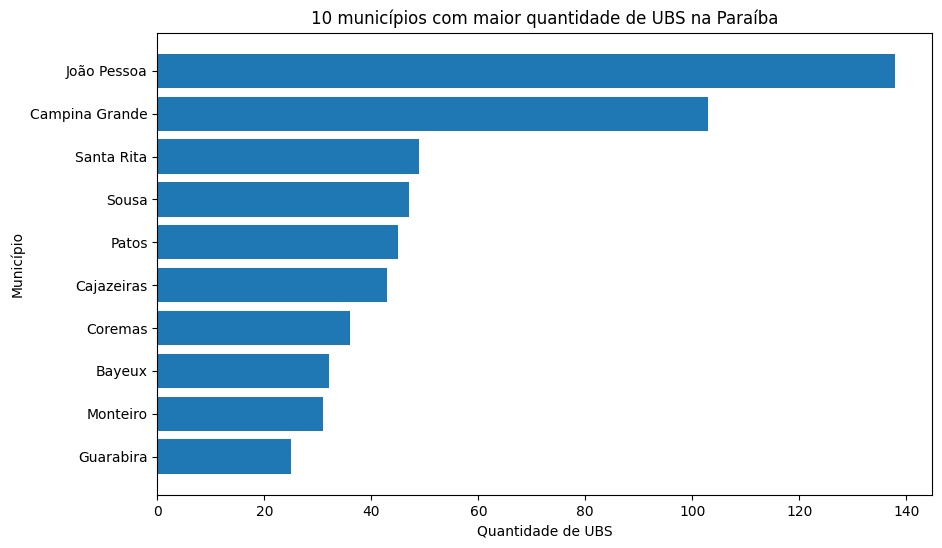

In [ ]:
import matplotlib.pyplot as plt

top10 = ubs_por_municipio.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["MUNICIPIO"],
    top10["QUANTIDADE_UBS"]
)

plt.xlabel("Quantidade de UBS")
plt.ylabel("Município")
plt.title("10 municípios com maior quantidade de UBS na Paraíba")

plt.gca().invert_yaxis()
plt.show()

 A distribuição das UBS entre os municípios analisados não é uniforme. João Pessoa apresenta a maior quantidade de unidades registradas na base, com 138 UBS, seguida por Campina Grande, com 103. Em seguida aparecem Santa Rita (49), Sousa (47), Patos (45) e Cajazeiras (43). O gráfico evidencia que João Pessoa e Campina Grande apresentam quantidades consideravelmente superiores às dos demais municípios entre os dez primeiros colocados.

#### 9.2 Quais municípios da Paraíba possuem a maior e a menor quantidade de UBS?

Nesta etapa, são identificados os municípios que apresentam as maiores e as menores quantidades de UBS registradas na base analisada.

In [ ]:
maiores = ubs_por_municipio.head(10)
menores = ubs_por_municipio.tail(10).sort_values("QUANTIDADE_UBS")

print("Municípios com maior quantidade de UBS:")
display(maiores)

print("\nMunicípios com menor quantidade de UBS:")
display(menores)

Municípios com maior quantidade de UBS:


,MUNICIPIO,QUANTIDADE_UBS
0,João Pessoa,138
1,Campina Grande,103
2,Santa Rita,49
3,Sousa,47
4,Patos,45
5,Cajazeiras,43
6,Coremas,36
7,Bayeux,32
8,Monteiro,31
9,Guarabira,25



Municípios com menor quantidade de UBS:


,MUNICIPIO,QUANTIDADE_UBS
211,Quixaba,1
212,Areia de Baraúnas,1
213,Santo André,1
214,Lastro,1
215,São José de Caiana,1
216,Curral Velho,1
217,São Domingos do Cariri,1
218,Mato Grosso,1
219,São José do Brejo do Cruz,1
220,Tenório,1


João Pessoa apresenta a maior quantidade de UBS registrada na base, com 138 unidades, seguida por Campina Grande, com 103. No extremo inferior da distribuição, diversos municípios apresentam apenas 1 UBS registrada. Entre eles estão Quixaba, Areia de Baraúnas, Santo André, Lastro, São José de Caiana, Curral Velho, São Domingos do Cariri, Mato Grosso, São José do Brejo do Cruz e Tenório. Portanto, observa-se uma diferença expressiva na quantidade absoluta de UBS entre os municípios analisados.

#### 9.3 Como as UBS estão distribuídas geograficamente na Paraíba?

Para analisar a distribuição geográfica das UBS, foram utilizadas as coordenadas de latitude e longitude disponíveis na base. Os registros sem coordenadas geográficas serão desconsiderados apenas nesta etapa da análise.

In [ ]:
ubs_mapa = df_pb.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

ubs_mapa.shape

(1730, 9)

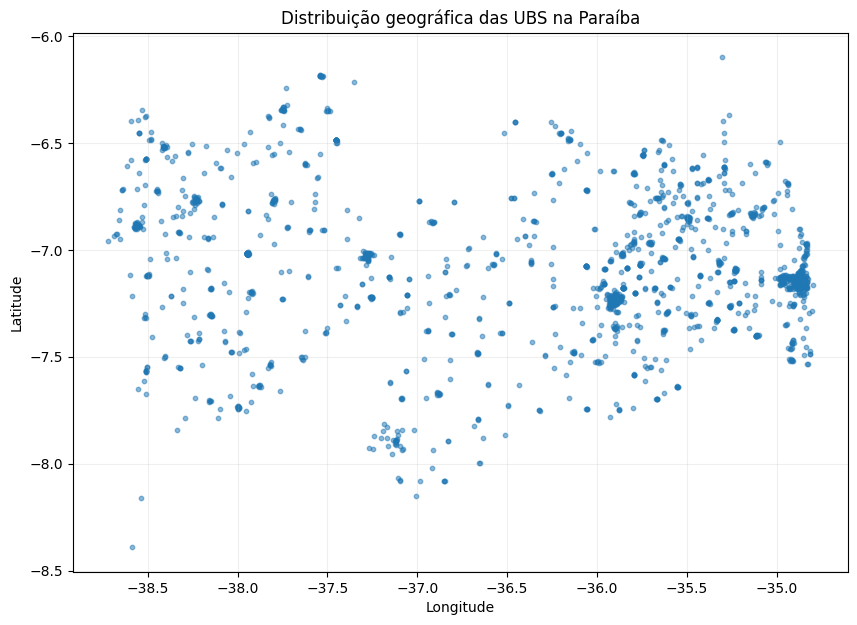

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    ubs_mapa["LONGITUDE"],
    ubs_mapa["LATITUDE"],
    s=10,
    alpha=0.5
)

plt.title("Distribuição geográfica das UBS na Paraíba")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)

plt.show()

A visualização das coordenadas geográficas mostra que as UBS estão distribuídas por diferentes regiões da Paraíba, porém sua concentração não ocorre de maneira uniforme. Observam-se áreas com maior densidade de unidades, especialmente na porção leste do estado, enquanto outras regiões apresentam pontos mais dispersos. Para esta análise geográfica foram utilizados 1.730 registros com coordenadas disponíveis; 59 registros foram desconsiderados apenas nesta visualização por não possuírem latitude e longitude.